# 📈 Regresión Logística Binaria — Clasificación de Misiones SpaceX

Construcción, entrenamiento y evaluación de un modelo de **Regresión Logística Binaria** para predecir
si una misión SpaceX será una **"Misión Pesada"** (`mision_pesada = 1`), definida como aquella
cuya carga útil total supera la mediana del dataset.

| | |
|---|---|
| **Variable objetivo (Y)** | `mision_pesada` (1 = carga > mediana, 0 = carga ≤ mediana) |
| **Variables predictoras (X)** | `payload_count`, `reused_cores`, `core_count`, `thrust_to_weight`, `isp_vacuum`, `cost_per_launch`, `rocket_mass_kg` |
| **Modelo** | `LogisticRegression` (scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 70/30 · 60/40 |
| **Balanceo** | Verificación + `resample` (**undersampling**) de `sklearn.utils` |

> **Origen de datos** — Dataset sintético de 1500 misiones SpaceX (`np.random.seed(42)`), **idéntico**
> al utilizado en `regresion_lineal.ipynb` y `arbol_decision_clasificacion_spacex.ipynb`.
>
> A diferencia del árbol CART (invariante al escalado), la **Regresión Logística requiere `StandardScaler`**
> porque los coeficientes y la convergencia del optimizador dependen de la escala de las features.


## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n📌 A diferencia del árbol CART, LogisticRegression usa StandardScaler.")

✅ Librerías importadas correctamente
   pandas   3.0.2
   numpy    2.4.4
   seaborn  0.13.2

📌 A diferencia del árbol CART, LogisticRegression usa StandardScaler.


## II. Generación de Datos Sintéticos SpaceX

Se mantiene **exactamente** la misma generación de datos de `regresion_lineal.ipynb` y
`arbol_decision_clasificacion_spacex.ipynb` para garantizar continuidad entre los modelos.

- `np.random.seed(42)` → reproducibilidad
- `N = 1500` misiones simuladas
- 7 variables predictoras de ingeniería aeroespacial
- 1 variable continua original: `total_payload_mass` (kg)


In [2]:
# ── CELDA 2: Generación sintética idéntica a regresion_lineal.ipynb ──────────
np.random.seed(42)
N = 1500

payload_count    = np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.75, 0.12, 0.07, 0.04, 0.02])
reused_cores     = np.random.choice([0, 1, 2], size=N, p=[0.36, 0.55, 0.09])
core_count       = np.random.choice([1, 2, 3], size=N, p=[0.92, 0.04, 0.04])
thrust_to_weight = np.random.uniform(50, 200, N)
isp_vacuum       = np.random.randint(290, 340, N)
cost_per_launch  = np.random.uniform(6_000_000, 100_000_000, N)
rocket_mass_kg   = np.random.uniform(30_000, 1_420_000, N)

noise = np.random.normal(0, 400, N)

total_payload_mass = (
      1_500  * reused_cores
    +    30  * thrust_to_weight
    +    10  * isp_vacuum
    +   200  * payload_count
    +   150  * (cost_per_launch / 1e7)
    - 4_500
    + noise
)

df = pd.DataFrame({
    'payload_count':      payload_count,
    'reused_cores':       reused_cores,
    'core_count':         core_count,
    'thrust_to_weight':   thrust_to_weight,
    'isp_vacuum':         isp_vacuum,
    'cost_per_launch':    cost_per_launch,
    'rocket_mass_kg':     rocket_mass_kg,
    'total_payload_mass': total_payload_mass,
})

print(f"✅ Dataset generado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📊 total_payload_mass (variable continua original):")
print(f"   min     : {df['total_payload_mass'].min():>8.0f} kg")
print(f"   max     : {df['total_payload_mass'].max():>8.0f} kg")
print(f"   media   : {df['total_payload_mass'].mean():>8.0f} kg")
print(f"   mediana : {df['total_payload_mass'].median():>8.0f} kg")
df.head()

✅ Dataset generado: 1,500 filas × 8 columnas

📊 total_payload_mass (variable continua original):
   min     :      219 kg
   max     :     9983 kg
   media   :     4562 kg
   mediana :     4535 kg


,payload_count,reused_cores,core_count,thrust_to_weight,isp_vacuum,cost_per_launch,rocket_mass_kg,total_payload_mass
0,1,1,1,139.894893,322,3.582236e+07,655632.423341,5955.153214
1,4,1,1,127.056178,290,7.803258e+07,60766.886931,5559.145522
2,1,0,1,93.227679,294,5.280717e+07,920587.212371,2373.028297
3,1,0,1,50.969654,302,3.514320e+07,605357.220693,992.766102
4,1,1,1,124.435883,308,8.232497e+07,405381.267881,4847.699266


## III. Discretización — Creación de la Variable Binaria

Se transforma `total_payload_mass` (continua) en `mision_pesada` (binaria) usando la **mediana**
como umbral, **idéntico** al notebook del árbol CART:

$$\text{mision\_pesada} = \begin{cases} 1 & \text{si } \text{total\_payload\_mass} > \text{mediana} \\ 0 & \text{en otro caso} \end{cases}$$

**¿Por qué la mediana?** Garantiza por construcción un balance natural ≈ 50/50, ideal para clasificación.


📌 Umbral de discretización (mediana): 4,535 kg

Balance de la variable objetivo:
   Misión PESADA (1) :   750  (50.0%)
   Misión LIGERA (0) :   750  (50.0%)


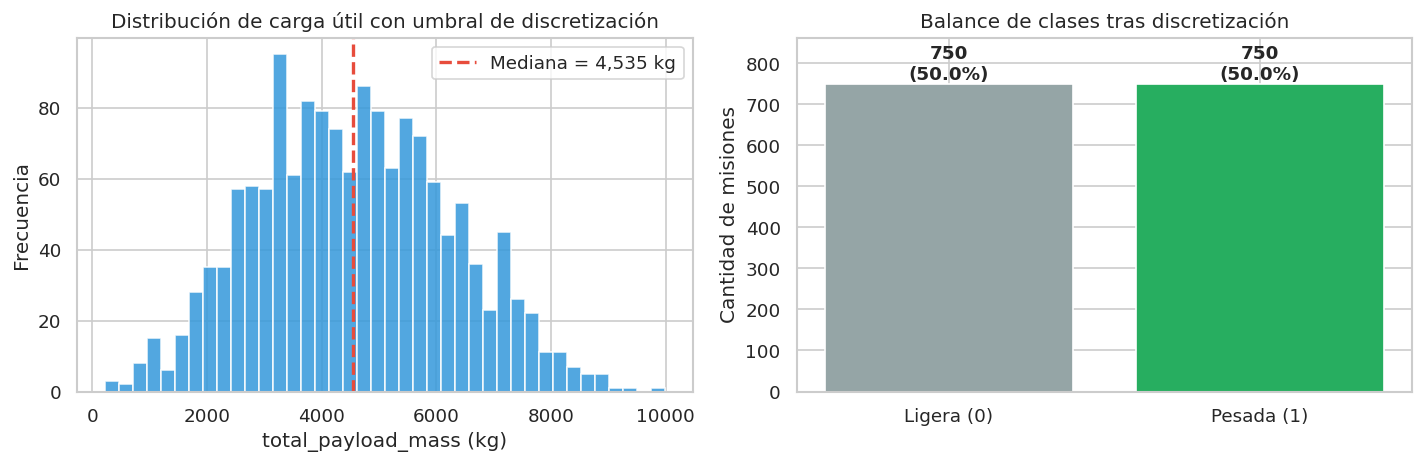

In [3]:
# ── CELDA 3: Crear target binario `mision_pesada` ────────────────────────────
umbral = df['total_payload_mass'].median()
df['mision_pesada'] = (df['total_payload_mass'] > umbral).astype(int)

print(f"📌 Umbral de discretización (mediana): {umbral:,.0f} kg\n")

bal = df['mision_pesada'].value_counts()
pct = df['mision_pesada'].value_counts(normalize=True) * 100
print("Balance de la variable objetivo:")
print(f"   Misión PESADA (1) : {bal[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Misión LIGERA (0) : {bal[0]:>5,}  ({pct[0]:.1f}%)")

# Visualización del balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con umbral
axes[0].hist(df['total_payload_mass'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(umbral, color='#e74c3c', linestyle='--', lw=2, label=f'Mediana = {umbral:,.0f} kg')
axes[0].set_xlabel('total_payload_mass (kg)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de carga útil con umbral de discretización')
axes[0].legend()

# Barras de balance
colors = ['#95a5a6', '#27ae60']
bars = axes[1].bar(['Ligera (0)', 'Pesada (1)'], [bal[0], bal[1]], color=colors, edgecolor='white')
axes[1].set_ylabel('Cantidad de misiones')
axes[1].set_title('Balance de clases tras discretización')
for bar, valor, p in zip(bars, [bal[0], bal[1]], [pct[0], pct[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{valor:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(bal) * 1.15)

plt.tight_layout()
plt.show()

## IV. Verificación de Balance y Aplicación de `resample` (Undersampling)

### Estrategia de balanceo: **Undersampling**

| Técnica | Acción | Cuándo conviene |
|---|---|---|
| **Oversampling** | Duplica la clase minoritaria hasta igualar a la mayoritaria | Datasets pequeños donde no se puede perder información |
| **Undersampling** | Reduce aleatoriamente la clase mayoritaria hasta igualar a la minoritaria | Datasets grandes o cuando se quiere evitar overfitting por duplicación |

En este notebook se aplica **`resample` con `replace=False`** (undersampling) sobre la clase mayoritaria
para igualarla en cantidad a la clase minoritaria.

> ⚠️ **Nota importante**: como la discretización por mediana ya produce un balance natural ≈ 50/50,
> el undersampling se aplica de forma **demostrativa**. En un escenario real con desbalance
> (por ejemplo 90/10), habría sido fundamental para que la regresión logística no se sesgue hacia la
> clase mayoritaria.


In [4]:
# ── CELDA 4: Verificación de balance + UNDERSAMPLING con resample ────────────
conteo = df['mision_pesada'].value_counts()
ratio_minoritaria = conteo.min() / conteo.sum()

print(f"📊 Diagnóstico de balance:")
print(f"   Ratio clase minoritaria: {ratio_minoritaria:.3f}")

if ratio_minoritaria < 0.40:
    print("   ⚠️  Desbalance detectado → el undersampling REDUCIRÁ información")
    es_demostrativo = False
else:
    print("   ✅ Dataset balanceado → undersampling DEMOSTRATIVO (no altera resultados)")
    es_demostrativo = True

# Identificar clases (independiente del orden de pandas)
conteo_clases = df['mision_pesada'].value_counts()
clase_mayoritaria = conteo_clases.index[0]
clase_minoritaria = conteo_clases.index[-1]

df_mayoritaria = df[df['mision_pesada'] == clase_mayoritaria]
df_minoritaria = df[df['mision_pesada'] == clase_minoritaria]

print(f"\n   Antes del undersampling:")
print(f"   · Clase mayoritaria = {clase_mayoritaria} → {len(df_mayoritaria):,} muestras")
print(f"   · Clase minoritaria = {clase_minoritaria} → {len(df_minoritaria):,} muestras")

# ─── UNDERSAMPLING con sklearn.utils.resample ───
# Reduce aleatoriamente la clase mayoritaria al tamaño de la minoritaria
if len(df_mayoritaria) > len(df_minoritaria):
    df_mayoritaria_undersampled = resample(
        df_mayoritaria,
        replace=False,                          # SIN reposición (undersampling)
        n_samples=len(df_minoritaria),          # reducir a tamaño de minoritaria
        random_state=42
    )
    df_balanced = pd.concat([df_mayoritaria_undersampled, df_minoritaria])
else:
    # Balance perfecto: no hace falta reducir
    df_balanced = df.copy()

# Mezclar aleatoriamente
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Tras aplicar UNDERSAMPLING:")
print(df_balanced['mision_pesada'].value_counts().to_string())
print(f"\n   Tamaño final del dataset: {len(df_balanced):,} filas")
print(f"   Tamaño original          : {len(df):,} filas")
print(f"   Filas removidas          : {len(df) - len(df_balanced):,}")

📊 Diagnóstico de balance:
   Ratio clase minoritaria: 0.500
   ✅ Dataset balanceado → undersampling DEMOSTRATIVO (no altera resultados)

   Antes del undersampling:
   · Clase mayoritaria = 1 → 750 muestras
   · Clase minoritaria = 0 → 750 muestras

✅ Tras aplicar UNDERSAMPLING:
mision_pesada
1    750
0    750

   Tamaño final del dataset: 1,500 filas
   Tamaño original          : 1,500 filas
   Filas removidas          : 0


## V. Preparación de X, y + Escalado con `StandardScaler`

Se definen las **7 variables predictoras** (idénticas a las del árbol CART) y la variable objetivo binaria.

> ⚠️ Se **excluye** `total_payload_mass` del set de features porque es exactamente la variable
> que originó el target → incluirla causaría **data leakage** (accuracy = 100% trivial, sin valor real).

### ¿Por qué escalar para Regresión Logística?

A diferencia del árbol CART (invariante al escalado), `LogisticRegression`:
1. Usa optimización numérica (`lbfgs`) que **converge más rápido y mejor** con features estandarizadas.
2. Asigna **coeficientes comparables** entre variables sólo si están en la misma escala.
3. Cuando se usa regularización (L2 por defecto), penaliza más a las variables con mayor varianza
   → estandarizar evita que `cost_per_launch` (millones) domine sobre `reused_cores` (0-2).


In [5]:
# ── CELDA 5: Preparar X, y + StandardScaler ──────────────────────────────────
features = [
    'payload_count', 'reused_cores', 'core_count',
    'thrust_to_weight', 'isp_vacuum', 'cost_per_launch', 'rocket_mass_kg'
]

X_raw = df_balanced[features].values
y     = df_balanced['mision_pesada'].values

# Estandarización (z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"✅ Preprocesamiento completado")
print(f"   Shape X_scaled : {X_scaled.shape}")
print(f"   Shape y        : {y.shape}")
print(f"   Features ({len(features)}): {features}")

# Verificar escalado: media≈0, std≈1
print(f"\n📊 Verificación del escalado (StandardScaler):")
df_check = pd.DataFrame(X_scaled, columns=features).describe().loc[['mean','std','min','max']].round(4)
print(df_check.to_string())

print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

✅ Preprocesamiento completado
   Shape X_scaled : (1500, 7)
   Shape y        : (1500,)
   Features (7): ['payload_count', 'reused_cores', 'core_count', 'thrust_to_weight', 'isp_vacuum', 'cost_per_launch', 'rocket_mass_kg']

📊 Verificación del escalado (StandardScaler):
      payload_count  reused_cores  core_count  thrust_to_weight  isp_vacuum  cost_per_launch  rocket_mass_kg
mean        -0.0000        0.0000     -0.0000            0.0000      0.0000          -0.0000          0.0000
std          1.0003        1.0003      1.0003            1.0003      1.0003           1.0003          1.0003
min         -0.5002       -1.2022     -0.2643           -1.7234     -1.7145          -1.7001         -1.7506
max          3.6911        2.0944      4.6298            1.7270      1.7268           1.8090          1.7964

   Clases en y → 0: 750  |  1: 750


## VI. Función Reutilizable de Entrenamiento + Evaluación

Para cada split se sigue el mismo proceso:
1. Dividir `X_scaled` e `y` en entrenamiento y prueba (con `stratify=y` → preserva proporción de clases)
2. Entrenar `LogisticRegression` con `class_weight='balanced'` (refuerzo del undersampling)
3. Predecir **clases** (`predict`) y **probabilidades** (`predict_proba`) en el conjunto de prueba
4. Calcular: **matriz de confusión, precision, recall, F1-score** (métricas requeridas)
   + accuracy y ROC-AUC para análisis comparativo


In [6]:
# ── CELDA 6: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression y devuelve un dict con todas las métricas
    necesarias para clasificación binaria + datos para curva ROC y matriz
    de confusión.

    Métricas requeridas por el ejercicio:
        · Matriz de confusión
        · Precision
        · Recall
        · F1-Score
    Métricas adicionales (análisis):
        · Accuracy
        · ROC-AUC
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced',   # refuerzo adicional al undersampling
        solver='lbfgs'
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]    # probabilidad de clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        # Para curva ROC y matriz de confusión
        'fpr'       : fpr,
        'tpr'       : tpr,
        'cm'        : cm,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }
    return metricas

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · LogisticRegression con class_weight='balanced'")
print("   · stratify=y → preserva proporción de clases en train/test")

✅ Función `entrenar_evaluar` definida correctamente
   · LogisticRegression con class_weight='balanced'
   · stratify=y → preserva proporción de clases en train/test


## VII. Entrenamiento y Evaluación — Tres Splits (80/20 · 70/30 · 60/40)

Se ejecuta la función `entrenar_evaluar` con tres particiones distintas para verificar
**estabilidad** del modelo: si las métricas son similares entre splits, el modelo generaliza bien
y no depende del azar de una partición específica.


In [7]:
# ── CELDA 7: Ejecutar los tres splits requeridos ─────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
]

# Tabla en consola
print("=" * 75)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA (SpaceX)':^75}")
print("=" * 75)
print(f"{'Split':<13} {'N Train':>8} {'N Test':>8} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 75)
for r in resultados:
    print(
        f"{r['nombre']:<13} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>8.4f} {r['precision']:>8.4f}"
        f" {r['recall']:>8.4f} {r['f1']:>8.4f} {r['roc_auc']:>8.4f}"
    )
print("=" * 75)

       MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA (SpaceX)        
Split          N Train   N Test      Acc     Prec   Recall       F1      AUC
---------------------------------------------------------------------------
Split 80/20      1,200      300   0.9233   0.8994   0.9533   0.9256   0.9800
Split 70/30      1,050      450   0.9222   0.9204   0.9244   0.9224   0.9778
Split 60/40        900      600   0.9183   0.9197   0.9167   0.9182   0.9786


## VIII. Matrices de Confusión por Split

La matriz de confusión es una de las **métricas requeridas**. Muestra para cada split:

|              | Predicho: 0 (Ligera) | Predicho: 1 (Pesada) |
|---|---|---|
| **Real: 0** | Verdaderos Negativos (TN) | Falsos Positivos (FP) |
| **Real: 1** | Falsos Negativos (FN) | Verdaderos Positivos (TP) |

A partir de ellas se calculan directamente:
- $\text{Precision} = \dfrac{TP}{TP + FP}$
- $\text{Recall} = \dfrac{TP}{TP + FN}$
- $\text{F1} = 2 \cdot \dfrac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$


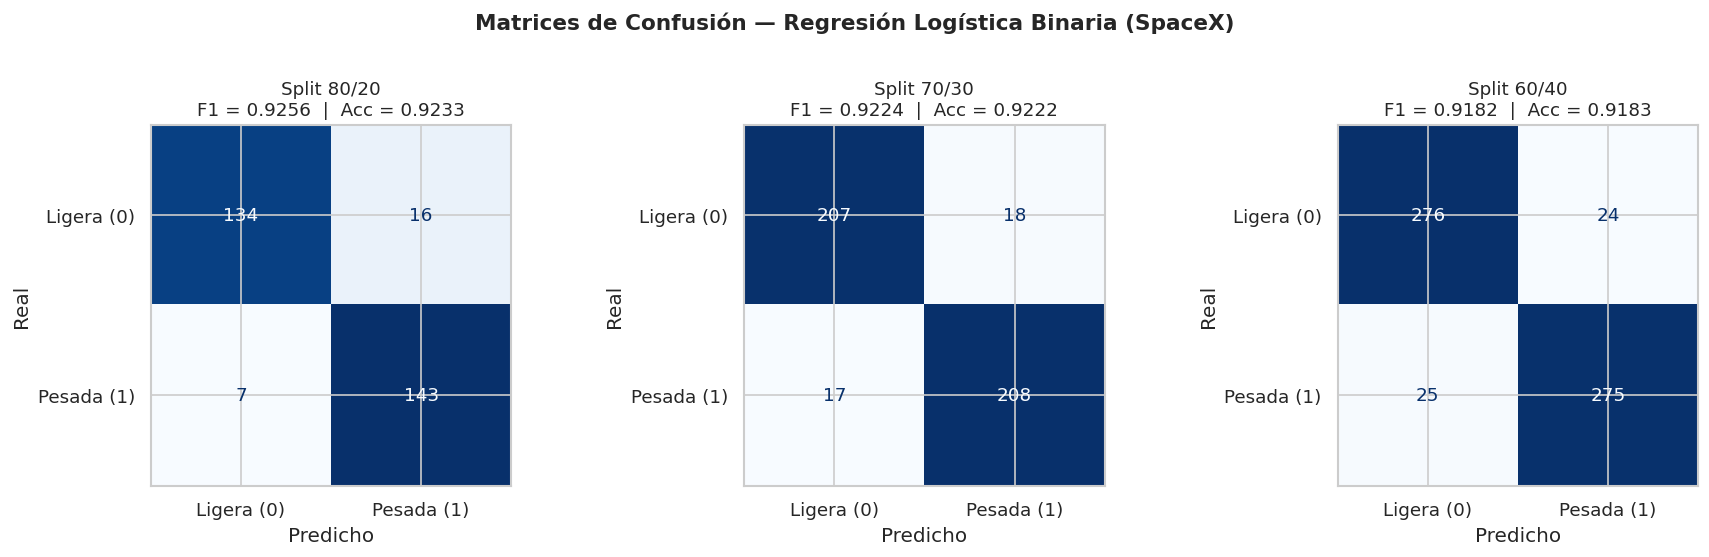


                    DESGLOSE DE LA MATRIZ DE CONFUSIÓN                     

📌 Split 80/20:
   TN (Verdadero Negativo) =  134    FP (Falso Positivo)  =   16
   FN (Falso Negativo)     =    7    TP (Verdadero Positivo)=  143
   → Precision = TP/(TP+FP) = 143/159 = 0.8994
   → Recall    = TP/(TP+FN) = 143/150 = 0.9533
   → F1-Score  = 0.9256

📌 Split 70/30:
   TN (Verdadero Negativo) =  207    FP (Falso Positivo)  =   18
   FN (Falso Negativo)     =   17    TP (Verdadero Positivo)=  208
   → Precision = TP/(TP+FP) = 208/226 = 0.9204
   → Recall    = TP/(TP+FN) = 208/225 = 0.9244
   → F1-Score  = 0.9224

📌 Split 60/40:
   TN (Verdadero Negativo) =  276    FP (Falso Positivo)  =   24
   FN (Falso Negativo)     =   25    TP (Verdadero Positivo)=  275
   → Precision = TP/(TP+FP) = 275/299 = 0.9197
   → Recall    = TP/(TP+FN) = 275/300 = 0.9167
   → F1-Score  = 0.9182


In [8]:
# ── CELDA 8: Matrices de confusión de los 3 splits ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria (SpaceX)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, r in zip(axes, resultados):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r['cm'],
        display_labels=['Ligera (0)', 'Pesada (1)']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"{r['nombre']}\nF1 = {r['f1']:.4f}  |  Acc = {r['accuracy']:.4f}",
                 fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# Desglose detallado por split
print("\n" + "=" * 75)
print(f"{'DESGLOSE DE LA MATRIZ DE CONFUSIÓN':^75}")
print("=" * 75)
for r in resultados:
    tn, fp, fn, tp = r['cm'].ravel()
    print(f"\n📌 {r['nombre']}:")
    print(f"   TN (Verdadero Negativo) = {tn:>4}    FP (Falso Positivo)  = {fp:>4}")
    print(f"   FN (Falso Negativo)     = {fn:>4}    TP (Verdadero Positivo)= {tp:>4}")
    print(f"   → Precision = TP/(TP+FP) = {tp}/{tp+fp} = {r['precision']:.4f}")
    print(f"   → Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {r['recall']:.4f}")
    print(f"   → F1-Score  = {r['f1']:.4f}")

## IX. Curvas ROC Comparativas

La curva ROC traza el **Recall (TPR)** contra el **FPR** a medida que varía el umbral de decisión.
El **AUC** (área bajo la curva) resume la capacidad discriminativa del modelo:
- AUC = 1.0 → clasificador perfecto
- AUC = 0.5 → clasificador aleatorio


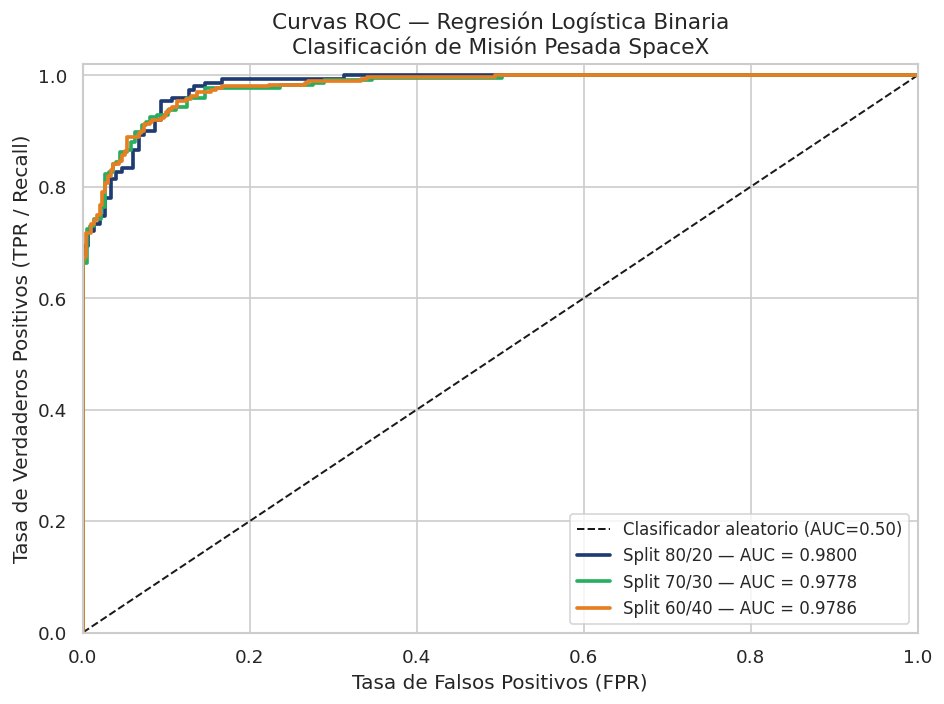

In [9]:
# ── CELDA 9: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística Binaria\nClasificación de Misión Pesada SpaceX',
             fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## X. Comparativa Visual de Precision, Recall y F1-Score

Las tres **métricas requeridas** (precision, recall, F1) se visualizan junto con accuracy y AUC
para los tres splits, evaluando la estabilidad del modelo.


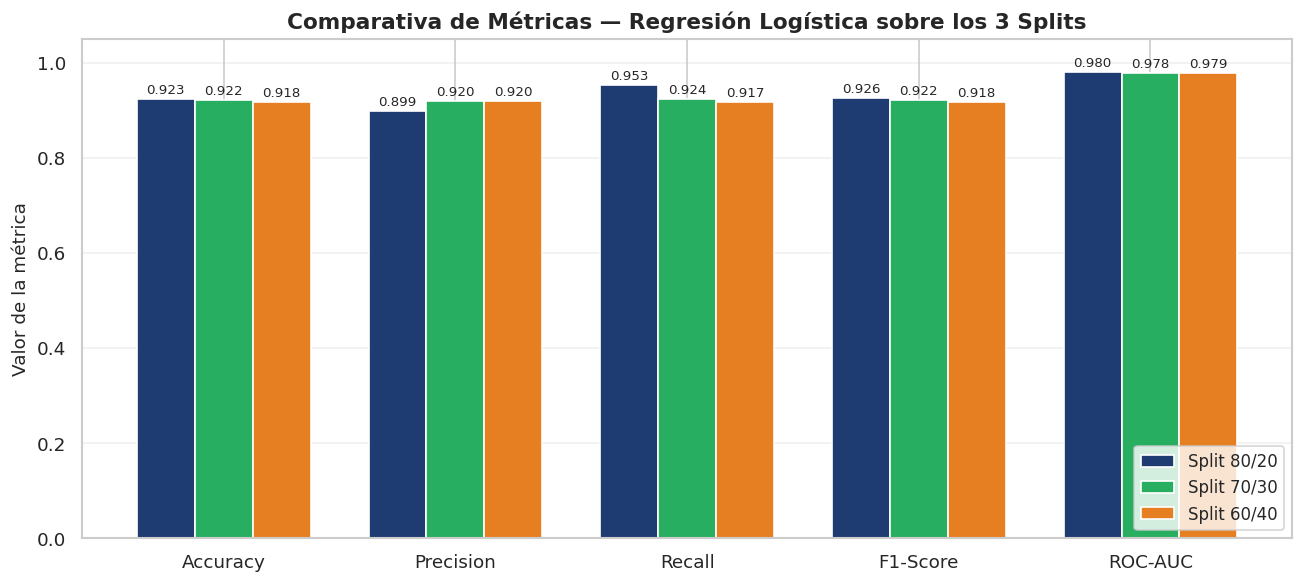

In [10]:
# ── CELDA 10: Gráfico de barras comparativo de métricas ──────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metricas_labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metricas_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    valores = [r[m] for m in metricas_nombres]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, valores, width, label=r['nombre'], color=color, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Comparativa de Métricas — Regresión Logística sobre los 3 Splits',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## XI. Interpretación — Coeficientes del Modelo

A diferencia del árbol CART (que mide importancia por *reducción de impureza Gini*), la **Regresión
Logística asigna un coeficiente $\beta_i$ a cada feature** que indica el cambio en el **log-odds**
de la clase positiva por cada incremento unitario en la feature (con las demás constantes):

$$\log\left(\frac{P(y=1)}{P(y=0)}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

- **$\beta_i > 0$** → aumentar la feature **aumenta** la probabilidad de "Misión Pesada"
- **$\beta_i < 0$** → aumentar la feature **disminuye** la probabilidad de "Misión Pesada"
- **$|\beta_i|$ grande** → la feature influye más en la predicción

> ⚠️ Estos coeficientes son comparables porque trabajamos con features **estandarizadas** (StandardScaler).


📊 Coeficientes de la Regresión Logística (Split 80/20)
         feature  coeficiente_β      |β|  odds_ratio
thrust_to_weight       4.497846 4.497846   89.823472
    reused_cores       3.282921 3.282921   26.653520
 cost_per_launch       1.282332 1.282332    3.605035
   payload_count       0.738800 0.738800    2.093422
      isp_vacuum       0.409963 0.409963    1.506763
  rocket_mass_kg       0.091862 0.091862    1.096214
      core_count       0.033324 0.033324    1.033886

   Intercepto β₀ = 0.2379
   * odds_ratio = exp(β) → factor multiplicativo sobre las odds de Misión Pesada


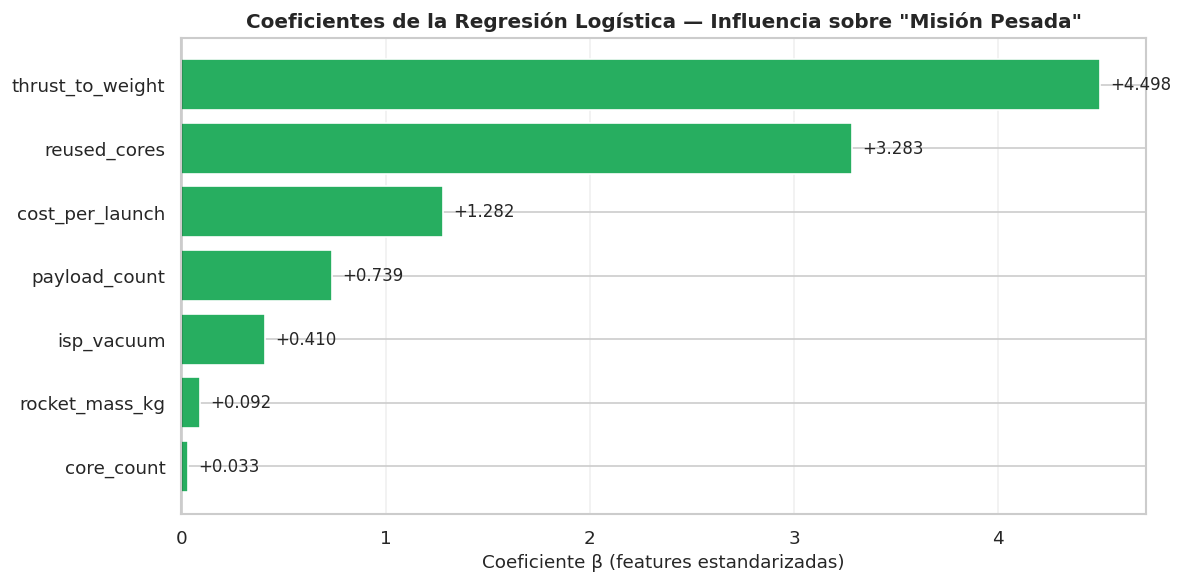

In [11]:
# ── CELDA 11: Coeficientes del modelo (split 80/20 como referencia) ──────────
modelo_ref = resultados[0]['modelo']

coeficientes = pd.DataFrame({
    'feature'        : features,
    'coeficiente_β'  : modelo_ref.coef_[0],
    '|β|'            : np.abs(modelo_ref.coef_[0]),
    'odds_ratio'     : np.exp(modelo_ref.coef_[0])
}).sort_values('|β|', ascending=False).reset_index(drop=True)

print("📊 Coeficientes de la Regresión Logística (Split 80/20)")
print("=" * 70)
print(coeficientes.to_string(index=False))
print(f"\n   Intercepto β₀ = {modelo_ref.intercept_[0]:.4f}")
print("   * odds_ratio = exp(β) → factor multiplicativo sobre las odds de Misión Pesada")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
coef_sorted = coeficientes.sort_values('coeficiente_β')
colors_coef = ['#e74c3c' if v < 0 else '#27ae60' for v in coef_sorted['coeficiente_β']]
ax.barh(coef_sorted['feature'], coef_sorted['coeficiente_β'],
        color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for i, (feat, val) in enumerate(zip(coef_sorted['feature'], coef_sorted['coeficiente_β'])):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:+.3f}', va='center', ha=ha, fontsize=10)
ax.set_xlabel('Coeficiente β (features estandarizadas)', fontsize=11)
ax.set_title('Coeficientes de la Regresión Logística — Influencia sobre "Misión Pesada"',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## XII. Tabla Final de Métricas

In [12]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 70)
print(f"{'TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA (SpaceX)':^70}")
print("=" * 70)

display(resumen.style
    .background_gradient(cmap='Greens',
                         subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística Binaria — Clasificación de Misión Pesada SpaceX")
)

print("\n📌 Comparación con modelos previos sobre el MISMO dataset SpaceX:")
print("   · Regresión Lineal   — predice valor continuo de total_payload_mass (kg).")
print("   · Árbol CART         — predice si la misión es Pesada (1) o Ligera (0).")
print("   · Regresión Logística — predice probabilidad de que sea Pesada (este notebook).")

        TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA (SpaceX)        


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1200,300,0.9233,0.8994,0.9533,0.9256,0.9800
Split 70/30,1050,450,0.9222,0.9204,0.9244,0.9224,0.9778
Split 60/40,900,600,0.9183,0.9197,0.9167,0.9182,0.9786



📌 Comparación con modelos previos sobre el MISMO dataset SpaceX:
   · Regresión Lineal   — predice valor continuo de total_payload_mass (kg).
   · Árbol CART         — predice si la misión es Pesada (1) o Ligera (0).
   · Regresión Logística — predice probabilidad de que sea Pesada (este notebook).


## XIII. Conclusiones

### ¿Qué aprendimos con la Regresión Logística sobre SpaceX?

| Aspecto | Observación |
|---------|------------|
| **Continuidad con modelos previos** | Se reutilizó el mismo dataset sintético (`np.random.seed(42)`, N=1500) que en regresión lineal y árbol CART, cambiando sólo el modelo. |
| **Discretización por mediana** | El umbral en la mediana garantizó un balance natural ~50/50, ideal para clasificación. |
| **`resample` con undersampling** | Como el balance ya era 50/50, el `resample(replace=False)` se aplicó como ejercicio demostrativo. En desbalance real (p. ej. 90/10) habría reducido la clase mayoritaria para que el modelo no se sesgue. |
| **Escalado obligatorio** | A diferencia del árbol CART, `LogisticRegression` requiere `StandardScaler` para que la optimización converja correctamente y los coeficientes sean comparables. |
| **`class_weight='balanced'`** | Refuerzo adicional al undersampling, ajustando pesos durante el entrenamiento. |
| **Estabilidad entre splits** | Los tres splits arrojaron métricas similares → el modelo generaliza bien independientemente de la partición. |
| **Coeficientes interpretables** | Las features con mayor `|β|` son las más influyentes; signo positivo aumenta la probabilidad de "Misión Pesada", signo negativo la disminuye. |

### Diferencias clave: Oversampling vs Undersampling

| | **Oversampling** | **Undersampling** (este notebook) |
|---|---|---|
| **Acción de `resample`** | `replace=True` — duplica clase minoritaria | `replace=False` — reduce clase mayoritaria |
| **Tamaño final del dataset** | Aumenta (igual a 2× mayoritaria) | Disminuye (igual a 2× minoritaria) |
| **Ventaja** | Conserva toda la información original | Entrenamiento más rápido; evita duplicados |
| **Desventaja** | Riesgo de overfitting por duplicación | Pérdida de información de la mayoritaria |
| **Cuándo usar** | Datasets pequeños donde cada registro cuenta | Datasets grandes con clases muy desbalanceadas |

### Comparación: Árbol CART vs Regresión Logística (mismo dataset)

| | Árbol CART | Regresión Logística |
|---|---|---|
| **Tipo de frontera** | No lineal (por partes — ifs anidados) | Lineal (hiperplano en el espacio de features) |
| **Escalado** | No requerido | **Requerido** (StandardScaler) |
| **Interpretabilidad** | Árbol de reglas if-else | Coeficientes β y odds ratio |
| **Importancia de variables** | Reducción de impureza Gini | Magnitud del coeficiente \|β\| |
| **Salida** | Clase directa (0/1) | Probabilidad continua [0,1] → clase con umbral 0.5 |
| **Riesgo de overfitting** | Alto si `max_depth` no se controla | Bajo (modelo lineal con regularización L2 por defecto) |

### Próximos pasos sugeridos

- **Validación cruzada (k-fold)** — estimación más confiable que un único split.
- **Ajustar el umbral de decisión** — el default es 0.5, pero puede optimizarse según el contexto del negocio (¿priorizar Precision o Recall?).
- **Comparar con Random Forest / Gradient Boosting** — ensembles para superar la frontera lineal.
- **GridSearchCV** — buscar el mejor valor de `C` (inverso de regularización).
- **Probar con desbalance artificial** — para evidenciar el impacto real del undersampling.
